# KNN for the shoting analysis of an NBA player

This project aims to use the k-nearest-neighbors to evaluate the shotchart of an NBA player. The idea is to use the principle that, given a location on the field, the k-nearest shots can suggest the outcome as a percentage, given by the fraction of them that the player has made. The dataset is downloaded with the [nba_api](https://github.com/swar/nba_api) (Copyright (c) 2018 Swar Patel).

In [1]:
from nba_api.stats.endpoints import shotchartdetail
import pandas as pd
from nba_api.stats.static import teams
from nba_api.stats.static import players
import os
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import json


In [2]:
def k_nn(x,X,ks):
    dist=(x*np.ones((X.shape[0],2))).transpose()-X.transpose()[0:2]
    dist=dist**2 
    dist=sum(dist)
    idx = np.argsort(dist)

    #ks=[1,2,3,4,5,10,15,20,25,30,50,100]
    p=[]
    for k in ks:
        nn=X.transpose()[2,idx[0:k]]
        p.append(sum(nn)/k)

    return p

def plot_campo():
    R=2375/10
    Rx=R*np.cos(np.linspace(0,np.pi,100))
    Ry=R*np.sin(np.linspace(0,np.pi,100))
    bsx=-R*np.ones(100)
    bsy=np.linspace(-46,0,100)
    b=250
    bx=-b*np.ones(100)
    by=np.linspace(-46,423,100)
    plt.plot(Rx,Ry,c="white")
    plt.plot(bsx,bsy,c="white")
    plt.plot(-bsx,bsy,c="white")
    plt.plot(bx,by,c="white")
    plt.plot(-bx,by,c="white")
    plt.plot(np.linspace(-b,b,100),423*np.ones(100),c="white")
    plt.plot(np.linspace(-b,b,100),-46*np.ones(100),c="white")
    

    return 0


As a personal choice, I picked Luka Dončić, both in the Los Angeles Lakers and Dallas Mavericks phases.

In [3]:
team=teams.find_teams_by_city("dallas")[0]
print(team)
team_id=team["id"]
team_2=teams.find_teams_by_city("los angeles")[1]
print(team_2)
team_id_2=team_2["id"]

player=players.find_players_by_full_name("Luka Dončić")[0]
print(player)
player_id=player["id"]


{'id': 1610612742, 'full_name': 'Dallas Mavericks', 'abbreviation': 'DAL', 'nickname': 'Mavericks', 'city': 'Dallas', 'state': 'Texas', 'year_founded': 1980}
{'id': 1610612747, 'full_name': 'Los Angeles Lakers', 'abbreviation': 'LAL', 'nickname': 'Lakers', 'city': 'Los Angeles', 'state': 'California', 'year_founded': 1948}
{'id': 1629029, 'full_name': 'Luka Dončić', 'first_name': 'Luka', 'last_name': 'Dončić', 'is_active': True}


I decided to use the statistics from the entire career of the player, this means that the shots are not really independent. It is clear that the season, such as the type of game or the game itself, can make a shot influence another. I don't consider this kind of correlation and I obtain a big dataset with all the shots, attempted or made, by Luka Dončić in his career from 2018, up to now.

In [4]:
if os.path.isfile("Data/data.json"):
    df=pd.read_json("Data/data.json",orient="records")

else:
    for anno in range(18,26):
        season="20"+str(anno)+"-"+str(anno+1)
        print(season)
        if anno==18:
            dfs=dfs=shotchartdetail.ShotChartDetail(player_id=player_id,team_id=team_id,season_nullable=season,context_measure_simple="FGA")
            df=dfs.data_sets[0].get_data_frame()
            dfs=dfs=shotchartdetail.ShotChartDetail(player_id=player_id,team_id=team_id,season_nullable=season,context_measure_simple="FGA",season_type_all_star="Playoffs")
            df2=dfs.data_sets[0].get_data_frame()
            df=pd.concat([df,df2],axis=0)
            print(df.shape)
            print(sum(df["SHOT_MADE_FLAG"]==1))
        if anno<=24 and anno>18:
            dfs=dfs=shotchartdetail.ShotChartDetail(player_id=player_id,team_id=team_id,season_nullable=season,context_measure_simple="FGA")
            df2=dfs.data_sets[0].get_data_frame()
            df=pd.concat([df,df2],axis=0)
            dfs=dfs=shotchartdetail.ShotChartDetail(player_id=player_id,team_id=team_id,season_nullable=season,context_measure_simple="FGA",season_type_all_star="Playoffs")
            df2=dfs.data_sets[0].get_data_frame()
            df=pd.concat([df,df2],axis=0)
            print(df2.shape)
            print(sum(df2["SHOT_MADE_FLAG"]==1))
        if anno>=24:
            dfs=dfs=shotchartdetail.ShotChartDetail(player_id=player_id,team_id=team_id_2,season_nullable=season,context_measure_simple="FGA")
            df2=dfs.data_sets[0].get_data_frame()
            df=pd.concat([df,df2],axis=0)
            dfs=dfs=shotchartdetail.ShotChartDetail(player_id=player_id,team_id=team_id_2,season_nullable=season,context_measure_simple="FGA",season_type_all_star="Playoffs")
            df2=dfs.data_sets[0].get_data_frame()
            df=pd.concat([df,df2],axis=0)
            print(df2.shape)
            print(sum(df2["SHOT_MADE_FLAG"]==1))

    df.to_json("Data/data.json",orient="records")

In [5]:
df.describe()

,GAME_ID,GAME_EVENT_ID,PLAYER_ID,TEAM_ID,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE
count,1.202600e+04,12026.000000,12026.0,1.202600e+04,12026.000000,12026.000000,12026.000000,12026.000000,12026.000000,12026.000000,12026.0,12026.000000,1.202600e+04
mean,2.429381e+07,306.675287,1629029.0,1.610613e+09,2.340762,5.017878,28.364045,15.548478,-15.167803,128.061616,1.0,0.467986,2.022297e+07
std,6.183695e+06,196.216369,0.0,1.892573e+00,1.120275,3.380452,17.617404,10.580814,100.363490,101.119534,0.0,0.498995,2.191538e+04
min,2.180001e+07,7.000000,1629029.0,1.610613e+09,1.000000,0.000000,0.000000,0.000000,-244.000000,-46.000000,1.0,0.000000,2.018102e+07
25%,2.200040e+07,117.000000,1629029.0,1.610613e+09,1.000000,2.000000,13.000000,5.000000,-85.750000,29.000000,1.0,0.000000,2.021020e+07
50%,2.220058e+07,316.000000,1629029.0,1.610613e+09,2.000000,5.000000,29.000000,15.000000,-1.000000,113.000000,1.0,0.000000,2.022103e+07
75%,2.240098e+07,451.000000,1629029.0,1.610613e+09,3.000000,8.000000,43.750000,26.000000,43.000000,226.000000,1.0,1.000000,2.024042e+07
max,4.240016e+07,842.000000,1629029.0,1.610613e+09,6.000000,11.000000,59.000000,78.000000,240.000000,769.000000,1.0,1.000000,2.026033e+07


Here we have a first representation of the shotchart.

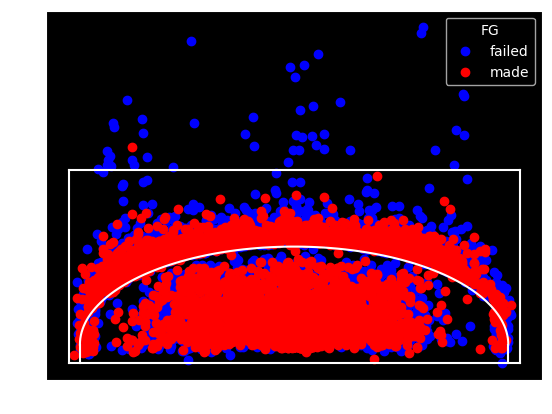

In [6]:


labels={1:"made",0:"failed"}
colors={1:"red",0:"blue"}


plt.figure()
plt.style.use('dark_background')
for i in range(2):
    mask=df.SHOT_MADE_FLAG==i
    plt.scatter(df.LOC_X[mask],df.LOC_Y[mask],c=colors[i],label=labels[i])
plot_campo()
plt.legend(title="FG")
plt.savefig("Images/shotchart.png")



## Fisrt analysis
As a first approach to the problem, I perform the k-NN algorithm to a uniform partition of the half-court, using the entire dataset with several values of $k$. The output is a proportion of the shot made for every location and every chosen value of $k$.

In [7]:

ks=[1,2,3,4,5,10,15,20,25,30,50,100]
if os.path.isfile("results.json"):
    with open('Results/results.json') as f:
        results= json.load(f)
        
else:
    X=df.loc[:,["LOC_X","LOC_Y","SHOT_MADE_FLAG"]]
    X=np.array(X)
    results=dict()
    for i in tqdm.tqdm(range(min(df.LOC_X),max(df.LOC_X),10)):
        for j in range(min(df.LOC_Y),max(df.LOC_Y),10):
            x=np.array([i,j])
            p=k_nn(x,X,ks)
            key='('+str(i)+','+str(j)+')'
            results[key]=p


    with open("Results/results.json","w") as f:
        json.dump(results,f,indent=4)


  0%|          | 0/49 [00:00<?, ?it/s]

100%|██████████| 49/49 [00:01<00:00, 29.47it/s]


The following table of plots gives us an idea of the output while varying the value of $k$. But which value of $k$ is the best for this problem?

/tmp/ipykernel_51991/3900804669.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


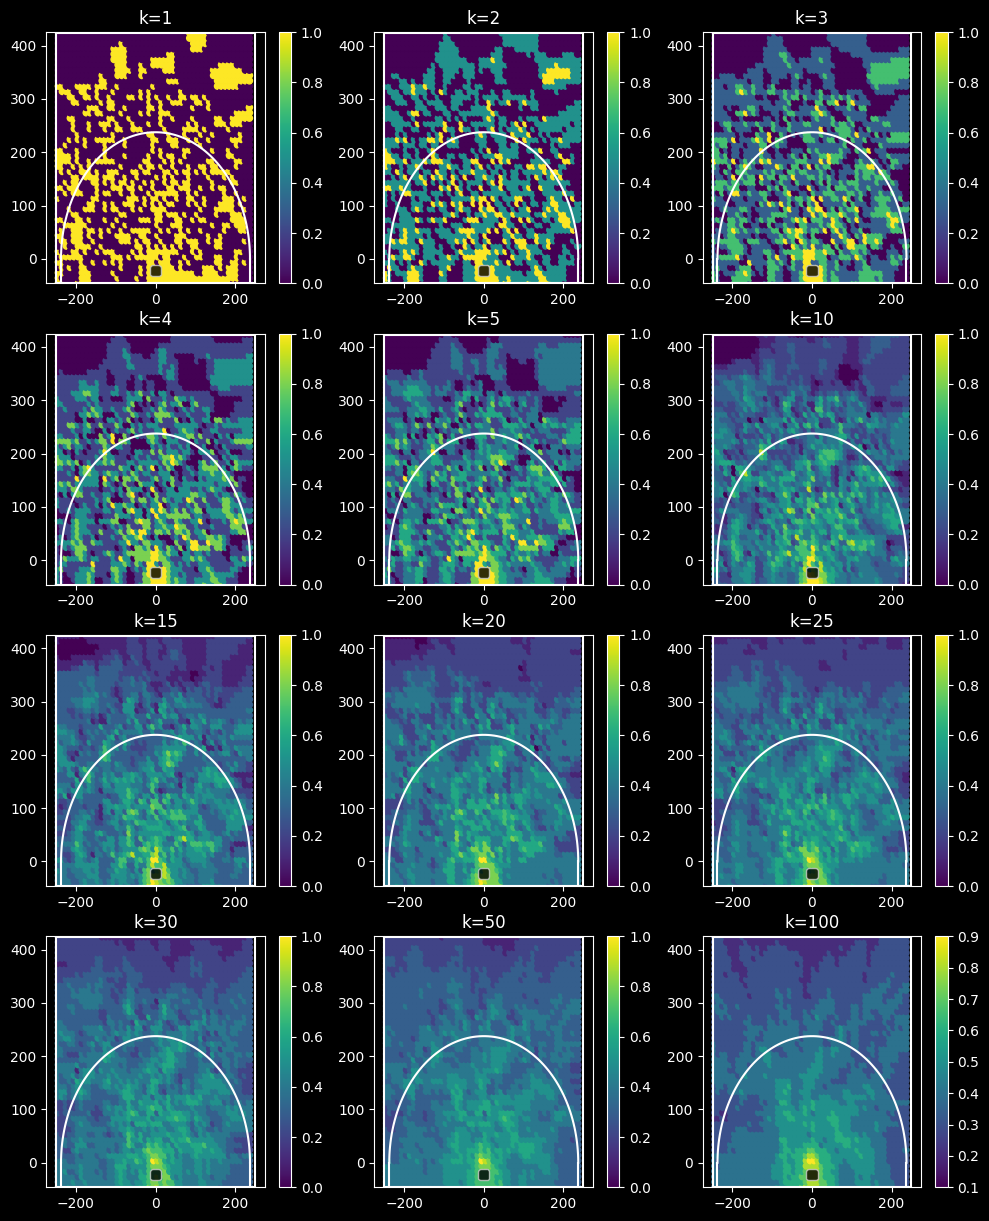

In [8]:

coordinate=list(results.keys())
coordinate=[(int(i.split(",")[0].split("(")[1]),int(i.split(",")[1].split(")")[0])) for i in coordinate ]
xs=[x[0] for x in coordinate]
ys=[x[1] for x in coordinate]
xss=np.array(xs)
xss=xss.reshape(49,82)
yss=np.array(ys)
yss=yss.reshape(49,82)
plt.figure(figsize=(12, 15))
for j,k in enumerate(ks):
    colors=[results["("+str(x)+","+str(y)+")"][j] for x,y in zip(xs,ys)]
    #colormesh=np.array(colors)
    #colormesh=colormesh.reshape(49,82)
    colors=[np.round(c,1) for c in colors ]
    plt.subplot(4,3,j+1)
    plt.scatter(xs,ys,s=20,c=colors)
    plt.ylim(-46, 425)
    #plt.pcolormesh(xss,yss,colormesh,cmap="RdBu")
    plt.colorbar()
    plt.legend()
    plot_campo()
    t="k="+str(k)
    plt.title(t)
plt.savefig("Images/panel.png")

## Training a K-NN
I adopted a model selection strategy and I defined a different version of the previous k-NN, where only a part of the dataset is used to predict the outcome of the other part. To have a more stable result, I used the **cross validation** selecting 4 of 5 portion of the dataset and varying the validation set. For each validation set, I computed a cross-entropy loss to evaluate the performances of the model with a given $k$. To sort the distances only once per configuration, the k-NN function returns the loss value for every value of $k$ between 1 and 100.

In [9]:
from sklearn.model_selection import KFold 
from sklearn.metrics import log_loss
from tqdm import tqdm
np.random.RandomState(42)

def train_k_nn(X,y):

    # sampling the dataset
    k_fold=KFold(5,shuffle=True)
    k_loss=losses=0.0*np.ones(100)
    for i, (train_index, test_index) in enumerate(k_fold.split(X.transpose())):
        train_set=X[:,train_index].transpose()
        train_label=y[train_index]
        test_set=X[:,test_index].transpose()
        test_label=y[test_index]
        loss=0.0*np.ones(100)
        losses=0.0*np.ones(100)
        #print(train_set.shape)
        print("fold",i)
        for x,y_true in tqdm(zip(test_set,test_label),total=len(test_set)):
            
            
            dist=(x*np.ones_like(train_set))-train_set
            dist=dist**2 
            dist=dist.transpose()
            dist=sum(dist)
            idx = np.argsort(dist)
            #print(len(idx))
            y_true=np.array([y_true])
            for k in range(1,101):
                nn=train_label[idx[0:k]]
                y_pred=np.array([sum(nn)/k])
                
                loss[k-1]=log_loss(y_true,y_pred,labels=np.array([0,1]))
            losses=losses+loss
        k_loss=k_loss+losses
    k_loss=k_loss/5
    return k_loss

if os.path.isfile("Results/train_results.json"):
    with open('Results/train_results.json') as f:
        losses= json.load(f)
        losses=np.array(losses)

else:
    X=np.stack((df["LOC_X"],df["LOC_Y"]))
    y=df["SHOT_MADE_FLAG"].values
    losses=train_k_nn(X,y)
    with open("Results/train_results.json","w") as f:
        json.dump(list(losses),f,indent=4)

The loss per value of $k$ is shown in the following plot, where I highlighted the value of the "elbow". $k=8$ seems to be the best choice.

8


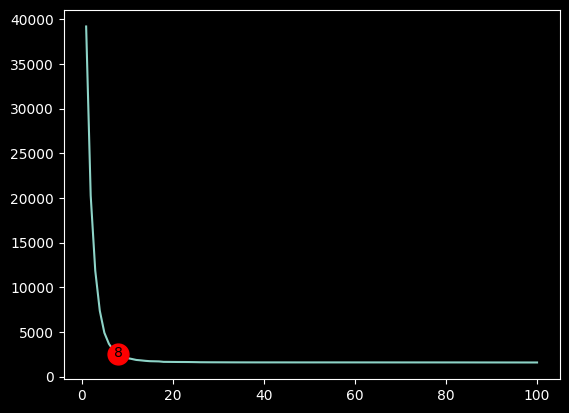

In [10]:
l1=losses[0]
l100=losses[-1]
Delta_loss=l100-l1
max_dist=0
k_elbow=0
for k in range(1,101):
    dist=np.abs(Delta_loss*k-99*losses[k-1]+99*l1-Delta_loss)/np.sqrt(Delta_loss**2+99**2)
    if dist>max_dist:
        max_dist=dist
        k_elbow=k
print(k_elbow)
plt.plot(list(range(1,101)),losses)
plt.plot(k_elbow,losses[k_elbow-1],"o",c="red",markersize=15)
plt.text(k_elbow*0.9,0.9*losses[k_elbow-1],str(k_elbow),c="black")
plt.savefig("Images/loss.png")

I repeated the first analysis but only for the best value of $k$, obtaining the following results.

In [11]:

k=8
X=df.loc[:,["LOC_X","LOC_Y","SHOT_MADE_FLAG"]]
X=np.array(X)
results=dict()
xs=list(range(min(df.LOC_X),-min(df.LOC_X)+10,10))
ys=list(range(min(df.LOC_Y),max(df.LOC_Y),10))
(X_grid,Y_grid)=np.meshgrid(xs,ys)
print(X_grid.shape,Y_grid.shape)
ps=np.zeros_like(X_grid,dtype=float)  
for i in tqdm(range(X_grid.shape[0])):
    for j in range(X_grid.shape[1]):
        x=np.array([X_grid[i,j],Y_grid[i,j]])
        p=k_nn(x,X,[k])
        #print(i,j,p)
        ps[i,j]=p[0]



(82, 50) (82, 50)


  0%|          | 0/82 [00:00<?, ?it/s]

100%|██████████| 82/82 [00:01<00:00, 52.32it/s]


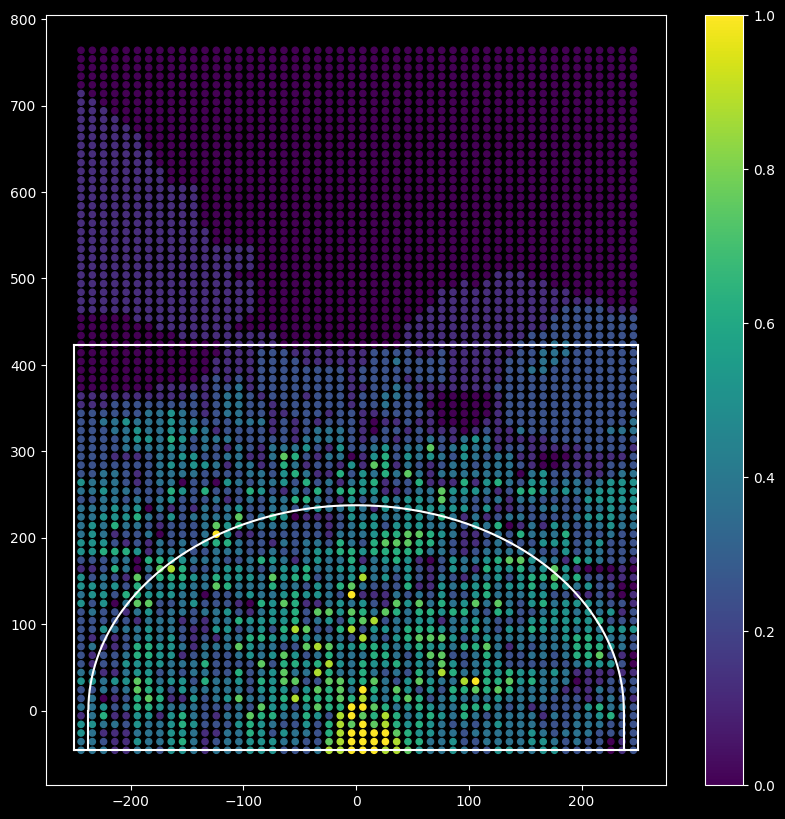

In [12]:
plt.figure(figsize=(10,10))
#plt.pcolormesh(X_grid,Y_grid,ps)
plt.scatter(X_grid.ravel(),Y_grid.ravel(),c=ps.ravel(),cmap="viridis",s=20)
plot_campo()
plt.colorbar()
plt.savefig("Images/final_plot.png")

As we can see, and as we can imagine, the yellow and green dots are less dense with the distance from the basket, except for the location just behind the 3-points line, where we can observe a little step, due to the fact that shooting just inside the area is much less convenient. Moreover, we can observe that the green points are denser on the left side of the court (the right one of the plot), in particular there is a little green spot on the left side of the court, and quite far from the 3-points line - approximatively at the coordinates $(230,250)$- that shows a general preferred sport for the long-long-distance shots - for an example, see [this video](https://www.youtube.com/watch?v=_7FizQwWlO0).  